# Figure 3: Score–affinity validation

Generates three panels showing the relationship between Rosetta total_score and experimental binding affinity, both pooled across alleles and broken down per-allele.

- **Panel A**: `rosetta_best_score` vs log₁₀(IC50), pooled across all alleles. Density contours + linear trendline + Spearman ρ.
- **Panel B**: `rosetta_best_score` vs log₁₀(Kd), pooled.
- **Panel C**: Per-allele Spearman ρ distribution, one open circle per allele (n ≥ 10), side-by-side IC50 vs Kd. Horizontal bar = median. Labels are restricted to well-sampled alleles (n ≥ `LABEL_MIN_N`, default 50): the three highest ρ and the single lowest ρ per column.

Each panel saves separately as PNG (300 dpi) and PDF, sized for *Scientific Data* dimensions. Combined assembly cell at the bottom builds `figure3_combined.{png,pdf}`. Combine in Keynote with panel letters added in 14 pt bold.

## Setup

In [1]:
from __future__ import annotations
from paths import DATA_ROOT, MHC_DB_ROOT, CLUSTER_ROOT  # roots; override with PEPBIND3D_* env vars

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, gaussian_kde
from adjustText import adjust_text

# === Paths ===
HF_DIR   = DATA_ROOT / "huggingface"
#FIG_DIR  = DATA_ROOT / "IEDB_validation/figure3_panels"
#FIG_DIR.mkdir(parents=True, exist_ok=True)

# === Figure sizing (Scientific Data conventions) ===
MM = 1 / 25.4
COL1_WIDTH = 89  * MM     # ~3.5 in single-column
COL2_WIDTH = 183 * MM     # ~7.2 in double-column

# === Plot style (matches Figure 2) ===
FONT_SIZE = 8
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         FONT_SIZE,
    'axes.labelsize':    FONT_SIZE,
    'axes.titlesize':    FONT_SIZE,
    'xtick.labelsize':   FONT_SIZE,
    'ytick.labelsize':   FONT_SIZE,
    'legend.fontsize':   FONT_SIZE,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

# === Color palette ===
ACCENT_RED      = '#CC3311'   # reference lines / thresholds
THRESHOLD_COLOR = '#CC3311'   # alias used in some figures
TREND_GREY      = '#333333'   # trend lines
GRID_GREY       = '#dddddd'   # background grid

## Load and prepare data

In [2]:
from paths import DATA_ROOT, MHC_DB_ROOT, CLUSTER_ROOT  # roots; override with PEPBIND3D_* env vars
df = pd.read_csv(HF_DIR / 'metadata.csv')
print(f'Total rows in metadata.csv:        {len(df):,}')

# Drop flagged entries (curation-excluded)
df = df[~df['flagged'].astype(bool)].copy()
print(f'After dropping flagged:            {len(df):,}')

# Scores come from metadata.csv itself (release/add_release_columns.py).
# Do NOT merge scores_out/score_summary.csv: it covers only the 49,268 v1
# pairs and predates the re-dock of the 1,162 content-defective ones, so it
# would cut the dataset by more than half and restore their old scores
# (median I_sc_best -11.60 REU against -68.57 after the re-dock).
for _c in ('I_sc_best', 'reweighted_sc_best', 'total_score_best', 'pep_sc_best'):
    assert _c in df.columns, (f'metadata.csv lacks {_c}; regenerate it with '
                              'release/add_release_columns.py')
df['allele_dir'] = df['allele'].map(
    lambda a: (a[4:] if a.startswith('HLA-') else a).replace('*', '').replace(':', ''))
print(f"rows without I_sc_best: {df['I_sc_best'].isna().sum():,}")

# Drop censored measurements (assay detection limits, per Methods)
IC50_CENSOR_VALUES = {20000, 50000, 70000}
KD_CENSOR_VALUES   = {5000, 10000, 20000}
IC50_LABEL, KD_LABEL = 'IC50', 'Kd'

is_ic50 = df['measurement_type'] == IC50_LABEL
is_kd   = df['measurement_type'] == KD_LABEL
not_censored = (
    (is_ic50 & ~df['measurement_value'].isin(IC50_CENSOR_VALUES) & (df['measurement_value'] < 70000)) |
    (is_kd   & ~df['measurement_value'].isin(KD_CENSOR_VALUES)   & (df['measurement_value'] < 20000))
)
df = df[not_censored].copy()
df['log_value'] = np.log10(df['measurement_value'])

ic50_df = df[df['measurement_type'] == IC50_LABEL].copy()
kd_df   = df[df['measurement_type'] == KD_LABEL].copy()
print(f'After censoring filter:  IC50 n = {len(ic50_df):,}   Kd n = {len(kd_df):,}')

Total rows in metadata.csv:        118,985
After dropping flagged:            118,970
rows without I_sc_best: 0
After censoring filter:  IC50 n = 18,113   Kd n = 48,395


In [3]:
# Pooled Spearman correlations
from paths import DATA_ROOT, MHC_DB_ROOT, CLUSTER_ROOT  # roots; override with PEPBIND3D_* env vars

# I_sc is the primary metric and the one the manuscript reports. Switching this
# changes every number the notebook prints and every allele panel C labels, so
# leave it on I_sc unless deliberately rebuilding a secondary-metric version;
# the metric comparison itself lives in Table S6, not in a second figure.
PRIMARY_METRIC = 'I_sc_best'

METRIC_LABEL = {
    'I_sc_best':          'I_sc',
    'reweighted_sc_best': 'reweighted_sc',
    'total_score_best':   'total_score',
    'pep_sc_best':        'pep_sc',
}[PRIMARY_METRIC]

# All Figure 3 versions live under one parent, one subdir per metric.
FIG_PARENT = DATA_ROOT / "IEDB_validation/figure3_panels"
FIG_DIR = FIG_PARENT / METRIC_LABEL      # e.g. figure3/I_sc, figure3/reweighted_sc
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'PRIMARY_METRIC = {PRIMARY_METRIC}')
print(f'FIG_DIR        = {FIG_DIR}')
print(f'  exists: {FIG_DIR.exists()}')

In [4]:
rho_ic50, p_ic50 = spearmanr(ic50_df[PRIMARY_METRIC], ic50_df['log_value'])
rho_kd,   p_kd   = spearmanr(kd_df[PRIMARY_METRIC],   kd_df['log_value'])
print(f'Pooled Spearman ρ ({PRIMARY_METRIC} vs log10(affinity)):')
print(f'  IC50: ρ = {rho_ic50:+.3f}, p = {p_ic50:.2e}, n = {len(ic50_df):,}')
print(f'  Kd:   ρ = {rho_kd:+.3f}, p = {p_kd:.2e}, n = {len(kd_df):,}')

Pooled Spearman ρ (reweighted_sc_best vs log10(affinity)):
  IC50: ρ = +0.126, p = 3.00e-65, n = 18,113
  Kd:   ρ = +0.119, p = 2.57e-151, n = 48,395


In [5]:
# Per-allele Spearman correlations
MIN_N = 10   # minimum sample size to include an allele

def per_allele_rho(subset_df, score_col=PRIMARY_METRIC, value_col='log_value', min_n=MIN_N):
    results = []
    for allele, grp in subset_df.groupby('allele'):
        if len(grp) < min_n:
            continue
        rho, p = spearmanr(grp[score_col], grp[value_col])
        results.append({
            'allele': allele,
            'rho':    rho,
            'p':      p,
            'n':      len(grp),
            'sig':    p < 0.05,
        })
    return pd.DataFrame(results).sort_values('rho', ascending=False).reset_index(drop=True)

ic50_alleles = per_allele_rho(ic50_df)
kd_alleles   = per_allele_rho(kd_df)

print(f'Alleles with n >= {MIN_N}:')
print(f'  IC50: {len(ic50_alleles)} alleles')
print(f'        median ρ = {ic50_alleles["rho"].median():+.3f}')
print(f'        IQR      = [{ic50_alleles["rho"].quantile(0.25):+.3f}, {ic50_alleles["rho"].quantile(0.75):+.3f}]')
print(f'        {ic50_alleles["sig"].sum()} of {len(ic50_alleles)} significant at p < 0.05')
print(f'  Kd:   {len(kd_alleles)} alleles')
print(f'        median ρ = {kd_alleles["rho"].median():+.3f}')
print(f'        IQR      = [{kd_alleles["rho"].quantile(0.25):+.3f}, {kd_alleles["rho"].quantile(0.75):+.3f}]')
print(f'        {kd_alleles["sig"].sum()} of {len(kd_alleles)} significant at p < 0.05')

Alleles with n >= 10:
  IC50: 35 alleles
        median ρ = +0.161
        IQR      = [+0.040, +0.218]
        16 of 35 significant at p < 0.05
  Kd:   80 alleles
        median ρ = +0.135
        IQR      = [+0.070, +0.201]
        43 of 80 significant at p < 0.05


## Panel C label selection

Labels are restricted to **well-sampled** alleles (n ≥ `LABEL_MIN_N`) so that unstable
small-sample estimates are plotted but not highlighted. This matches the n ≥ 50
"well-sampled" threshold used in the manuscript text.


In [6]:
# Which alleles get labeled in Panel C.
# Restricted to well-sampled alleles so that unstable small-sample estimates
# (e.g. B*38:01, n=22; B*44:02, n=18) are plotted but not highlighted.
LABEL_MIN_N = 50


def pick_outlier_labels(frame, top_pos=3, top_neg=1, min_n=LABEL_MIN_N):
    """Alleles to label: `top_pos` highest rho + `top_neg` lowest rho, among n >= min_n."""
    well = frame.loc[frame['n'] >= min_n]
    if well.empty:
        return set()
    ranked = well.sort_values('rho', ascending=False)
    labels = set(ranked.head(top_pos)['allele'])
    if top_neg:
        labels |= set(ranked.tail(top_neg)['allele'])
    return labels


ic50_labels = pick_outlier_labels(ic50_alleles, top_pos=3, top_neg=1)
kd_labels   = pick_outlier_labels(kd_alleles,   top_pos=3, top_neg=1)
labels_by_metric = {'IC50': ic50_labels, 'Kd': kd_labels}

for metric, sel in labels_by_metric.items():
    print(f'{metric} labels ({len(sel)}):')
    frame = ic50_alleles if metric == 'IC50' else kd_alleles
    for _, r in frame[frame['allele'].isin(sel)].iterrows():
        print(f"  {r['allele']:<12} rho={r['rho']:+.3f}  p={r['p']:.3f}  n={r['n']}")


IC50 labels (4):
  B*53:01      rho=+0.320  p=0.000  n=132
  A*68:01      rho=+0.310  p=0.006  n=78
  A*01:01      rho=+0.258  p=0.000  n=197
  B*51:01      rho=-0.156  p=0.205  n=68
Kd labels (4):
  B*58:01      rho=+0.316  p=0.000  n=854
  A*26:02      rho=+0.286  p=0.000  n=169
  B*73:01      rho=+0.279  p=0.034  n=58
  B*40:13      rho=-0.093  p=0.496  n=56


## Helper: contour panel

In [7]:
def draw_score_vs_affinity(ax, df_subset, rho, pval, x_label, y_label,
                           n_contours=8, kde_grid=120,
                           x_clip=(0.001, 0.999), y_clip=(0.0001, 0.999999),
                           xlim=None, ylim=None):
    x = df_subset[PRIMARY_METRIC].values
    y = df_subset['log_value'].values
    n = len(df_subset)

    # Quantile-based defaults
    x_low, x_high = np.quantile(x, x_clip)
    y_low, y_high = np.quantile(y, y_clip)
    
    # Override with explicit limits if provided
    if xlim is not None:
        x_low, x_high = xlim
    if ylim is not None:
        y_low, y_high = ylim

    # KDE evaluated on clipped grid
    kde = gaussian_kde(np.vstack([x, y]))
    xi = np.linspace(x_low, x_high, kde_grid)
    yi = np.linspace(y_low, y_high, kde_grid)
    X, Y = np.meshgrid(xi, yi)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    ax.contour(X, Y, Z, levels=n_contours, colors='black',
               linewidths=0.5, alpha=0.7, zorder=3)

    # Trendline
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.array([x_low, x_high])
    ax.plot(x_line, slope * x_line + intercept,
            color='black', linewidth=1.0, alpha=0.85, zorder=4)

    # Annotation, top-right to avoid the trendline + KDE bulk on the left
    p_str = 'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'
    # Avoid rendering '-0.00' when rho rounds to zero from below.
    rho_disp = 0.0 if abs(rho) < 5e-3 else rho
    ax.text(0.97, 0.03,
            f'Spearman ρ = {rho_disp:+.2f}\n{p_str}\nn = {n:,}',
            transform=ax.transAxes, ha='right', va='bottom')

    ax.set_xlim(x_low, x_high)
    ax.set_ylim(y_low, y_high)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.minorticks_off()
    ax.yaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
    ax.xaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

In [8]:
for name, d in [('IC50', ic50_df), ('Kd', kd_df)]:
    x, y = d['I_sc_best'], d['log_value']
    print(f'{name}: I_sc [{x.min():.0f}, {x.max():.0f}]  '
          f'log [{y.min():.2f}, {y.max():.2f}]  '
          f'(1/99 pct: I_sc [{x.quantile(.01):.0f}, {x.quantile(.99):.0f}], '
          f'log [{y.quantile(.01):.2f}, {y.quantile(.99):.2f}])')

IC50: I_sc [-98, -39]  log [-2.77, 4.84]  (1/99 pct: I_sc [-87, -54], log [-0.64, 4.81])
Kd: I_sc [-102, -39]  log [-3.37, 4.30]  (1/99 pct: I_sc [-87, -54], log [-0.76, 4.25])


In [9]:
for name, d in [('IC50', ic50_df), ('Kd', kd_df)]:
    x, y = d[PRIMARY_METRIC], d['log_value']
    print(f'{name}: {PRIMARY_METRIC} full [{x.min():.0f}, {x.max():.0f}]  '
          f'1-99 pct [{x.quantile(.01):.0f}, {x.quantile(.99):.0f}]   '
          f'log [{y.min():.2f}, {y.max():.2f}]')

IC50: reweighted_sc_best full [-722, -451]  1-99 pct [-694, -569]   log [-2.77, 4.84]
Kd: reweighted_sc_best full [-733, -186]  1-99 pct [-700, -578]   log [-3.37, 4.30]


In [ ]:
# Per-panel axis limits, keyed on the metric. Hand-tuned windows and a metric
# toggle must not be able to drift apart: with the limits left on reweighted_sc
# while PRIMARY_METRIC was I_sc, every panel rendered blank and still carried a
# correct-looking rho annotation, because nothing raises when a window contains
# no data. The assert below is the guard.
AXIS_LIMITS = {
    'I_sc_best':          dict(IC50_XLIM=(-90, -45), IC50_YLIM=(-2, 6),
                               KD_XLIM=(-90, -50),   KD_YLIM=(-2, 5)),
    'reweighted_sc_best': dict(IC50_XLIM=(-710, -575), IC50_YLIM=(-2, 6),
                               KD_XLIM=(-720, -585),   KD_YLIM=(-2, 5)),
    'total_score_best':   dict(IC50_XLIM=(-1050, -830), IC50_YLIM=(-2, 6),
                               KD_XLIM=(-1050, -830),   KD_YLIM=(-2, 5)),
    'pep_sc_best':        dict(IC50_XLIM=(-40, 10), IC50_YLIM=(-2, 6),
                               KD_XLIM=(-40, 10),   KD_YLIM=(-2, 5)),
}
_lim = AXIS_LIMITS[PRIMARY_METRIC]
IC50_XLIM, IC50_YLIM = _lim['IC50_XLIM'], _lim['IC50_YLIM']
KD_XLIM,   KD_YLIM   = _lim['KD_XLIM'],   _lim['KD_YLIM']

for _name, _frame, _xl in (('IC50', ic50_df, IC50_XLIM), ('Kd', kd_df, KD_XLIM)):
    _inside = _frame[PRIMARY_METRIC].between(*_xl).mean()
    print(f'{_name}: {_inside:.1%} of points inside {_xl}')
    assert _inside > 0.90, (
        f'{_name} x-window {_xl} holds only {_inside:.1%} of {PRIMARY_METRIC} '
        f'(range {_frame[PRIMARY_METRIC].min():.0f} to '
        f'{_frame[PRIMARY_METRIC].max():.0f}) -- the panel would be blank or clipped')

## Panel A: rosetta_best_score vs log₁₀(IC50)

Pooled scatter with density contours and linear trendline. n is shown after censoring filter.

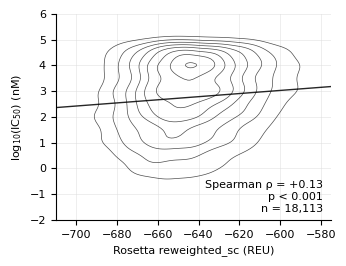

In [11]:
fig, ax = plt.subplots(figsize=(COL1_WIDTH, 2.7))
draw_score_vs_affinity(ax, ic50_df, rho_ic50, p_ic50,
                       x_label=f'Rosetta {METRIC_LABEL} (REU)',
                       y_label='log$_{10}$(IC$_{50}$) (nM)',
                       xlim=IC50_XLIM, ylim=IC50_YLIM)
fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_A_score_vs_ic50.png')
fig.savefig(FIG_DIR / 'panel_A_score_vs_ic50.pdf')
plt.show()

## Panel B: rosetta_best_score vs log₁₀(Kd)

Same structure as Panel A; Kd subset.

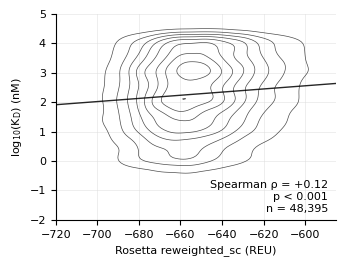

In [12]:
fig, ax = plt.subplots(figsize=(COL1_WIDTH, 2.7))
draw_score_vs_affinity(ax, kd_df, rho_kd, p_kd,
                       x_label=f'Rosetta {METRIC_LABEL} (REU)',
                       y_label='log$_{10}$(K$_\\mathrm{D}$) (nM)',
                       xlim=KD_XLIM, ylim=KD_YLIM)
fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_B_score_vs_kd.png')
fig.savefig(FIG_DIR / 'panel_B_score_vs_kd.pdf')
plt.show()

## Panel C: Per-allele Spearman ρ distribution

One open circle per allele with n ≥ `MIN_N` (10). Median ρ marked as a horizontal bar.
Labels come from `pick_outlier_labels`: the three highest ρ and the single lowest ρ
among alleles with n ≥ `LABEL_MIN_N` (50). Small-sample extremes such as B*38:01 (IC50)
and B*44:02 (Kd) are plotted but deliberately unlabeled.


In [ ]:
def draw_per_allele(ax, ic50_a, kd_a, labels_by_metric=None, jitter_seed=0):
    """Per-allele rho, one point per allele, marker area scaled by n.

    Size carries n on purpose. Without it the two highest IC50 points
    (A*26:01 rho 0.70 n=17, A*23:01 rho 0.69 n=29) sit above every labelled
    allele with no label, which reads as an omission rather than as the
    deliberate n >= 50 rule. Drawn small, they read as what they are: estimates
    from a few dozen measurements.
    """
    if labels_by_metric is None:
        labels_by_metric = {
            'IC50': pick_outlier_labels(ic50_a, top_pos=3, top_neg=1),
            'Kd':   pick_outlier_labels(kd_a,   top_pos=3, top_neg=1),
        }
    rng = np.random.default_rng(jitter_seed)
    positions = {'IC50': 0, 'Kd': 1}
    # Kd has more than twice as many alleles, so it needs a wider spread.
    jitter_w = {'IC50': 0.17, 'Kd': 0.30}

    n_all = np.concatenate([ic50_a['n'].values, kd_a['n'].values])
    lo, hi = np.log10(n_all.min()), np.log10(n_all.max())
    def marker_size(n):
        return 6 + 40 * (np.log10(n) - lo) / (hi - lo)

    all_texts = []
    for metric, frame in (('IC50', ic50_a), ('Kd', kd_a)):
        x_pos = positions[metric]
        w = jitter_w[metric]
        jitter = rng.uniform(-w, w, len(frame))
        rho_vals = frame['rho'].values
        x_vals = x_pos + jitter

        ax.scatter(x_vals, rho_vals, s=marker_size(frame['n'].values),
                   facecolor='none', edgecolor='black',
                   linewidth=0.55, alpha=0.75, zorder=3)

        med = frame['rho'].median()
        ax.hlines(med, x_pos - 0.38, x_pos + 0.38,
                  color='black', linewidth=1.6, zorder=5)

        targets = labels_by_metric[metric]
        for pos, (_, row) in enumerate(frame.iterrows()):
            if row['allele'] in targets:
                t = ax.text(x_vals[pos], row['rho'], row['allele'],
                            fontsize=FONT_SIZE - 1.5, va='center', ha='left',
                            zorder=6)
                all_texts.append(t)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['IC$_\\mathrm{50}$', 'K$_\\mathrm{D}$'])
    ax.set_xlim(-0.55, 1.85)
    ax.set_ylabel('Per-allele Spearman \u03c1')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.minorticks_off()
    ax.yaxis.grid(True, color=GRID_GREY, linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

    # Size key, so the reader can read n off the marker.
    for i, n_ref in enumerate((25, 250, 2500)):
        ax.scatter([1.62], [ax.get_ylim()[0] + 0.07 + i * 0.075],
                   s=marker_size(n_ref), facecolor='none', edgecolor='black',
                   linewidth=0.55, clip_on=False, zorder=6)
        ax.text(1.68, ax.get_ylim()[0] + 0.07 + i * 0.075, f'{n_ref:,}',
                fontsize=FONT_SIZE - 2, va='center', ha='left', clip_on=False)
    ax.text(1.62, ax.get_ylim()[0] + 0.07 + 3 * 0.075, 'n',
            fontsize=FONT_SIZE - 2, va='center', ha='center')

    if all_texts:
        adjust_text(all_texts, ax=ax,
                    arrowprops=dict(arrowstyle='-', color='grey',
                                    lw=0.4, shrinkA=1, shrinkB=3),
                    expand=(1.15, 1.35),
                    only_move={'text': 'xy', 'static': 'xy',
                               'explode': 'xy', 'pull': 'xy'})


fig, ax = plt.subplots(figsize=(COL1_WIDTH, 2.7))
draw_per_allele(ax, ic50_alleles, kd_alleles)
fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_C_per_allele_rho.png')
fig.savefig(FIG_DIR / 'panel_C_per_allele_rho.pdf')
plt.show()

## Combined figure

Three panels in a single row at COL2_WIDTH for the publication-ready figure.

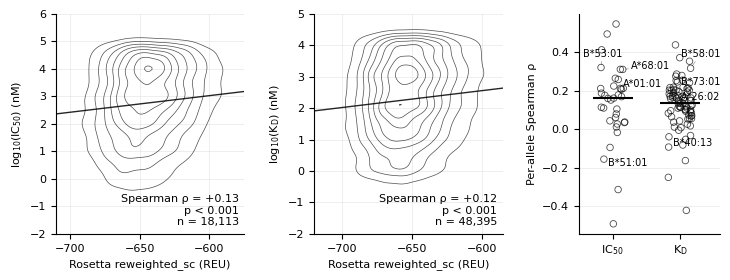

In [14]:
fig = plt.figure(figsize=(COL2_WIDTH, 2.7), constrained_layout=True)
# NOTE: constrained_layout manages spacing; do not pass wspace here.
axes = fig.subplots(1, 3, gridspec_kw={'width_ratios': [2, 2, 1.5]})
fig.set_constrained_layout_pads(w_pad=0.05, h_pad=0.05, wspace=0.10, hspace=0.0)

draw_score_vs_affinity(axes[0], ic50_df, rho_ic50, p_ic50,
                       x_label=f'Rosetta {METRIC_LABEL} (REU)',
                       y_label='log$_{10}$(IC$_{50}$) (nM)',
                       xlim=IC50_XLIM, ylim=IC50_YLIM)
draw_score_vs_affinity(axes[1], kd_df, rho_kd, p_kd,
                       x_label=f'Rosetta {METRIC_LABEL} (REU)',
                       y_label='log$_{10}$(K$_\\mathrm{D}$) (nM)',
                       xlim=KD_XLIM, ylim=KD_YLIM)
draw_per_allele(axes[2], ic50_alleles, kd_alleles, labels_by_metric)

fig.savefig(FIG_DIR / 'figure3_combined.png', dpi=1200)  # 1200 dpi is far above journal need
fig.savefig(FIG_DIR / 'figure3_combined.pdf')
plt.show()

## Summary

Panel files in `figure3_panels/`:

- `panel_A_score_vs_ic50.{png,pdf}`, pooled IC50 contour
- `panel_B_score_vs_kd.{png,pdf}`, pooled Kd contour
- `panel_C_per_allele_rho.{png,pdf}`, per-allele Spearman ρ strip plot
- `figure3_combined.{png,pdf}`, three-panel composite for the paper

**Combining in Keynote:**

1. New slide, set custom size 519 pt × 200 pt (= 183 × 70 mm, double-column figure, single-row).
2. Drop `figure3_combined.png`, or compose panels A/B/C individually for tighter alignment.
3. Add panel letters (A, B, C) as separate text boxes, Helvetica/Arial Bold 14 pt, upper-left of each panel.
4. Export at 300 dpi PNG.

**Things you may want to adjust:**

- `MIN_N` (minimum sample size to *plot* an allele), currently 10, which yields exactly the 28 IC50 and 25 Kd alleles reported in the manuscript. Confirmed; do not change without updating Table S2.
- Number of contour levels (`n_contours` in the helper), 8 by default; reduce to 5–6 for less busy contours.
- `LABEL_MIN_N` (minimum sample size to *label* an allele in Panel C), currently 50, matching the "well-sampled" threshold in the manuscript text. Labels are chosen by `pick_outlier_labels`, not hand-listed. Collisions are resolved automatically by `adjust_text`.